# SVM from scratch: hard-margin as a constrained optimization

Companion to `notes.md`'s "From-scratch implementation" section. We solve the exact
hard-margin SVM primal problem derived there,

$$\min_{w,b} \ \tfrac{1}{2}\|w\|^2 \qquad \text{s.t.} \qquad y_i(w^Tx_i+b) \geq 1 \ \ \forall i$$

directly with `scipy.optimize.minimize`, on a tiny 2D linearly-separable toy dataset —
no `sklearn.svm` used anywhere in this notebook. We then identify the support vectors
(points where the constraint is numerically tight) and visualize the fitted margin.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from scipy.optimize import minimize, NonlinearConstraint

np.set_printoptions(precision=4, suppress=True)

## Toy dataset

A small, clearly linearly-separable 2D dataset — two blobs with enough separation that
a hard margin (no slack) is guaranteed to be feasible. Labels are recoded to
$y_i \in \{-1, +1\}$, matching the sign convention used in `notes.md`'s derivation.

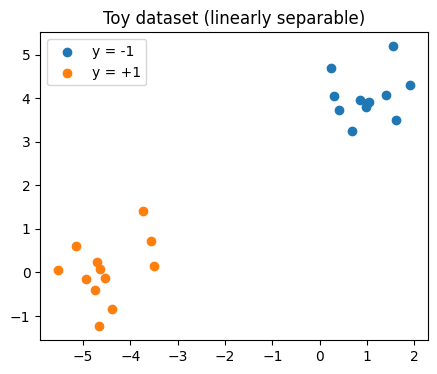

In [2]:
X, y_raw = make_blobs(n_samples=24, centers=2, cluster_std=0.6, random_state=3)
y = np.where(y_raw == 0, -1, 1)

plt.figure(figsize=(5, 4))
plt.scatter(X[y == -1, 0], X[y == -1, 1], color="tab:blue", label="y = -1")
plt.scatter(X[y == 1, 0], X[y == 1, 1], color="tab:orange", label="y = +1")
plt.legend()
plt.title("Toy dataset (linearly separable)")
plt.show()

## Solve the hard-margin primal directly

$\min_{w,b} \frac12\|w\|^2$ subject to $y_i(w^Tx_i+b) \geq 1$ for every point $i$ —
exactly the constrained quadratic program derived in `notes.md`'s Mathematical foundation
section, solved here with SLSQP (Sequential Least Squares Programming), which supports
nonlinear inequality constraints directly. This is not how production SVM solvers work
(they solve the dual, which scales far better — see `notes.md`'s Practical implementation
section) but it is a completely transparent, from-scratch way to see the same objective
being optimized.

In [3]:
def objective(params):
    w = params[:2]
    return 0.5 * np.dot(w, w)

def margin_constraint(params):
    w, b = params[:2], params[2]
    return y * (X @ w + b) - 1   # must be >= 0 for every point

constraint = NonlinearConstraint(margin_constraint, 0, np.inf)

result = minimize(
    objective,
    x0=np.zeros(3),
    method="SLSQP",
    constraints=[constraint],
)

assert result.success, result.message
w_opt, b_opt = result.x[:2], result.x[2]
print("Converged:", result.success)
print("w =", w_opt)
print("b =", b_opt)
print("margin width 2/||w|| =", 2 / np.linalg.norm(w_opt))

Converged: True
w = [-0.3668 -0.2069]
b = -0.07979553792490489
margin width 2/||w|| = 4.749077129131071


## Identify the support vectors

The support vectors are exactly the points where the margin constraint is tight:
$y_i(w^Tx_i+b) \approx 1$. Every other point sits strictly outside the margin
($y_i(w^Tx_i+b) > 1$) and, per `notes.md`'s Algorithm/Mental model sections, could be
removed from the training set without changing the fitted hyperplane at all.

In [4]:
margins = y * (X @ w_opt + b_opt)
print("Per-point margin values y_i(w^T x_i + b):")
print(margins)

support_mask = np.isclose(margins, 1, atol=1e-2)
print(f"\nNumber of support vectors: {support_mask.sum()} / {len(y)}")
print("Support vector coordinates:\n", X[support_mask])

Per-point margin values y_i(w^T x_i + b):
[1.4315 1.2746 1.6071 1.0018 1.8865 1.2449 1.6137 1.1345 1.0805 1.6863
 1.5979 1.2178 1.6703 1.7609 1.2087 1.     1.3933 1.0275 1.7041 1.1783
 1.72   1.7397 1.9373 1.    ]

Number of support vectors: 3 / 24
Support vector coordinates:
 [[ 0.6887  3.2351]
 [-3.7349  1.4022]
 [ 0.4017  3.7352]]


## Visualize the decision boundary, margin, and support vectors

Plot the fitted separating hyperplane $w^Tx+b=0$, the two margin boundaries
$w^Tx+b=\pm1$, and highlight the support vectors — the points touching the edges of
the margin corridor, matching the "widest street" mental model from `notes.md`.

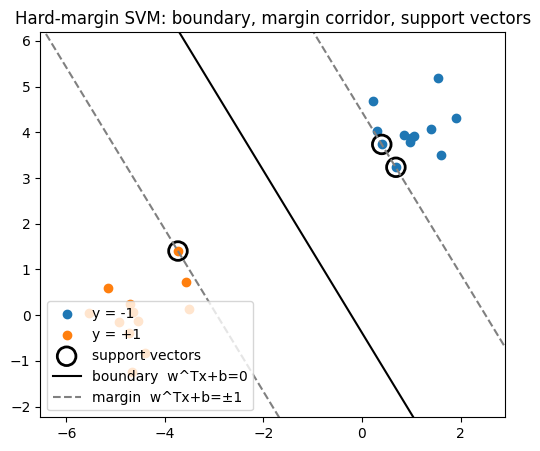

In [5]:
x_range = np.linspace(X[:, 0].min() - 1, X[:, 0].max() + 1, 200)

def boundary_x2(w, b, offset, x1_vals):
    # w1*x1 + w2*x2 + b = offset  ->  x2 = (offset - b - w1*x1) / w2
    return (offset - b - w[0] * x1_vals) / w[1]

plt.figure(figsize=(6, 5))
plt.scatter(X[y == -1, 0], X[y == -1, 1], color="tab:blue", label="y = -1")
plt.scatter(X[y == 1, 0], X[y == 1, 1], color="tab:orange", label="y = +1")
plt.scatter(
    X[support_mask, 0], X[support_mask, 1],
    s=180, facecolors="none", edgecolors="black", linewidths=2,
    label="support vectors",
)

plt.plot(x_range, boundary_x2(w_opt, b_opt, 0, x_range), color="black", label="boundary  w^Tx+b=0")
plt.plot(x_range, boundary_x2(w_opt, b_opt, 1, x_range), color="gray", linestyle="--", label="margin  w^Tx+b=±1")
plt.plot(x_range, boundary_x2(w_opt, b_opt, -1, x_range), color="gray", linestyle="--")

plt.ylim(X[:, 1].min() - 1, X[:, 1].max() + 1)
plt.xlim(X[:, 0].min() - 1, X[:, 0].max() + 1)
plt.legend(loc="best")
plt.title("Hard-margin SVM: boundary, margin corridor, support vectors")
plt.show()

## Sanity check: every point respects the margin

Confirm every training point satisfies the constraint it was optimized under
($y_i(w^Tx_i+b) \geq 1$, up to numerical tolerance) — i.e. the solver actually found a
feasible, correctly-separating hyperplane, not just a local stationary point of the
objective alone.

In [6]:
assert np.all(margins >= 1 - 1e-6), "Some point violates the hard margin constraint!"
print("All points satisfy y_i (w^T x_i + b) >= 1 (hard-margin constraint holds).")

All points satisfy y_i (w^T x_i + b) >= 1 (hard-margin constraint holds).
